In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_10K_pbmc-v1_atacseq',
    destination='scarf_datasets'
)

Downloading bucket files: 79995014 / 79995014 complete

Downloading bytes: 79995014 / 79995014 complete

In [3]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump()

Writing counts: 7 / 7 complete

In [5]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4
)

Computing ATAC initialization statistics: 6 / 6 complete

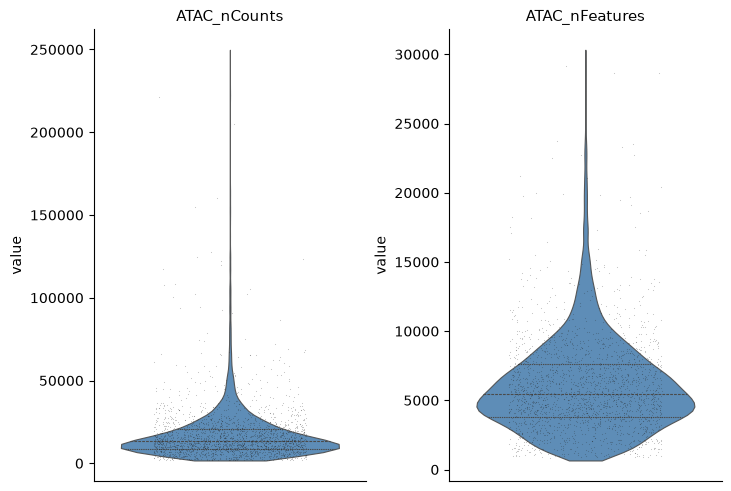

In [6]:
qc_cols = [
    c for c in ('ATAC_nCounts', 'ATAC_nFeatures')
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

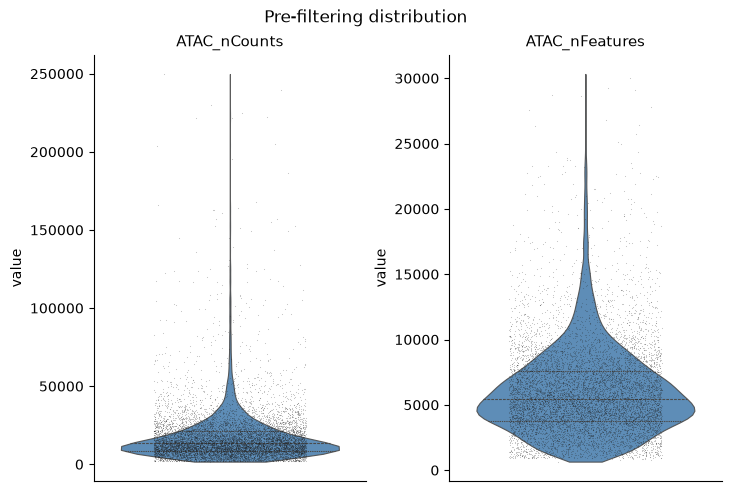

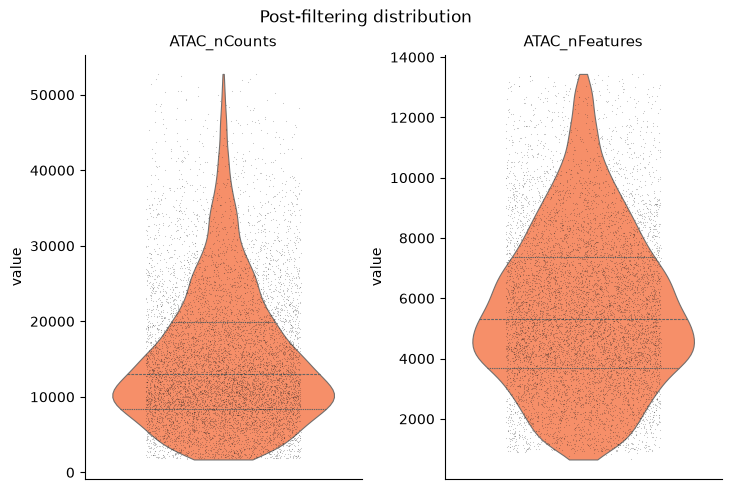

In [7]:
ds.auto_filter_cells(show_qc_plots=True)

In [8]:
ds.mark_prevalent_peaks(top_n=25000)

(ATAC) Calculating peak prevalence across cells: 6 / 6 complete

In [9]:
ds.run_normalization(feat_key='prevalent_peaks')
ds.run_lsi(dims=50, skip_first=True)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()

ds.load_graph()

Writing data: 7 / 7 complete

Fitting streaming LSI model (1/7): 7 / 7 complete

Fitting streaming LSI model (2/7): 7 / 7 complete

Fitting streaming LSI model (3/7): 7 / 7 complete

Fitting streaming LSI model (4/7): 7 / 7 complete

...

Calculating reduced coordinates: 7 / 7 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 176946 stored elements and shape (8426, 8426)>

In [10]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

Training UMAP: 500 / 500 complete

ArtifactRef(assay='ATAC', kind='embedding', artifact_id='6487c98ef4a6...')

In [11]:
ds.run_leiden_clustering(resolution=0.6)

ArtifactRef(assay='ATAC', kind='cluster_labels', artifact_id='ae3290381ebd...')

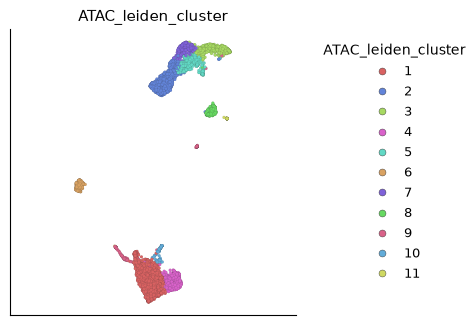

In [12]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    color_by='ATAC_leiden_cluster',
)

In [13]:
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='annotations',
    destination='scarf_datasets'
)

Downloading bucket files: 4397159 / 4397159 complete

Downloading bytes: 4397159 / 4397159 complete

In [14]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn=f'{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

Computing gene-score document frequency: 6 / 6 complete

Melding assay: 125 / 125 complete

Computing GeneScores initialization statistics: 17 / 17 complete

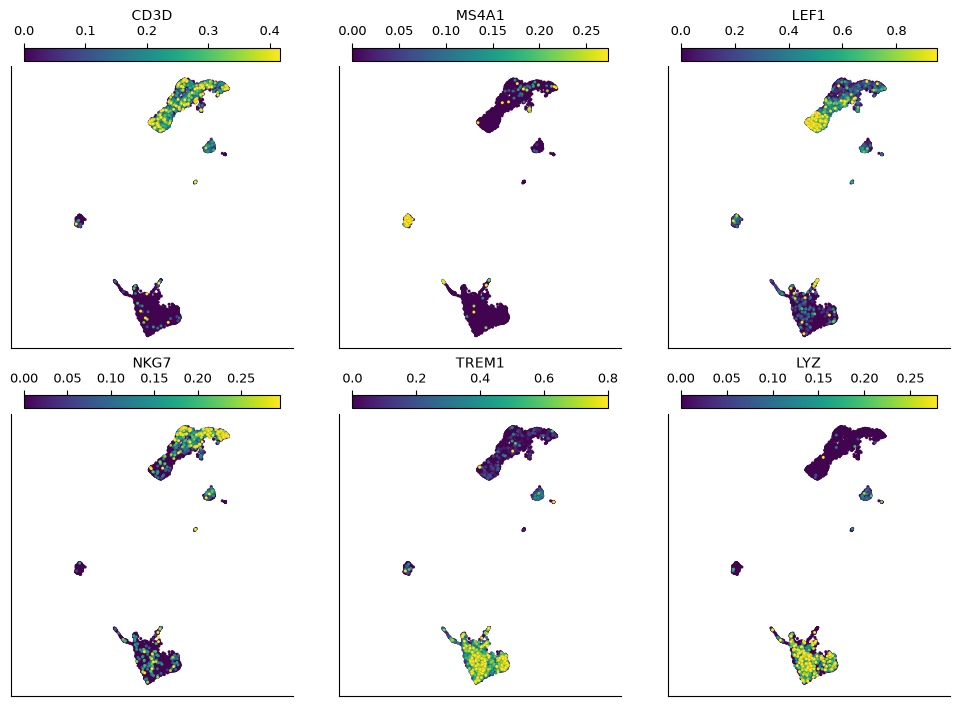

In [15]:
ds.plots.embedding(
    layout_key='ATAC_UMAP',
    from_assay='GeneScores',
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01,
    n_columns=3,
    sort_values=True,
)